In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from weather_engine.database import engine
from weather_engine.spatial import haversine


In [2]:
# Find the nearest cell to Afula (station 16) using haversine
afula_metadata = pd.read_sql("SELECT latitude, longitude FROM station_metadata WHERE station_id = 16", engine)
afula_lat, afula_lon = afula_metadata["latitude"].iloc[0], afula_metadata["longitude"].iloc[0]

cell_neighbors = pd.read_sql("SELECT * FROM cell_neighbors", engine)
cell_neighbors['dist_to_afula'] = cell_neighbors.apply(
    lambda r: haversine(afula_lat, afula_lon, r['lat'], r['lon']), axis=1
)
nearest = cell_neighbors.sort_values('dist_to_afula').iloc[0]
NEAREST_CELL_ID = int(nearest['cell_id'])
print(f"Nearest cell to Afula: cell_id={NEAREST_CELL_ID}, lat={nearest['lat']}, lon={nearest['lon']}, distance={nearest['dist_to_afula']:.2f} km")


Nearest cell to Afula: cell_id=33, lat=32.6, lon=35.3, distance=2.21 km


In [3]:
# Load ground truth (Afula) and interpolated cell data
afula = pd.read_sql("SELECT * FROM clean_station_data WHERE station_id = 16", engine)
afula['timestamp'] = pd.to_datetime(afula['timestamp'])
afula = afula.set_index('timestamp').sort_index()

interpolated = pd.read_sql(
    "SELECT * FROM cell_interpolated WHERE cell_id = :cid",
    engine, params={'cid': NEAREST_CELL_ID}
)
interpolated['timestamp'] = pd.to_datetime(interpolated['timestamp'])
interpolated = interpolated.drop(columns=['cell_id']).set_index('timestamp').sort_index()

forecasts = pd.read_sql(
    "SELECT * FROM cell_forecasts WHERE cell_id = :cid",
    engine, params={'cid': NEAREST_CELL_ID}
)
forecasts['timestamp'] = pd.to_datetime(forecasts['timestamp'])
forecasts = forecasts.drop(columns=['cell_id']).set_index('timestamp').sort_index()

print(f"Afula ground truth:  {len(afula):,} rows  ({afula.index.min()} – {afula.index.max()})")
print(f"Interpolated cell:   {len(interpolated):,} rows  ({interpolated.index.min()} – {interpolated.index.max()})")
print(f"Forecast cell:       {len(forecasts):,} rows  ({forecasts.index.min()} – {forecasts.index.max()})")


Afula ground truth:  52,608 rows  (2019-12-31 22:00:00 – 2025-12-31 21:00:00)
Interpolated cell:   51,796 rows  (2019-12-31 22:00:00 – 2025-12-31 21:00:00)
Forecast cell:       46,747 rows  (2020-06-29 18:00:00 – 2025-12-31 21:00:00)


## Interpolation Accuracy (RFSI vs. Afula Ground Truth)

Align on shared timestamps and compute MAE / RMSE per meteorological feature.


In [4]:
INTERP_FEATURES = ['rain', 'ws', 'td', 'rh', 'tdmax', 'tdmin', 'u_vec', 'v_vec']
UNITS = {
    'rain': 'mm/h', 'ws': 'm/s', 'td': '°C', 'rh': '%',
    'tdmax': '°C', 'tdmin': '°C', 'u_vec': 'm/s', 'v_vec': 'm/s'
}


# Align on shared timestamps
shared_interp = interpolated.index.intersection(afula.index)
interp_pred = interpolated.loc[shared_interp, INTERP_FEATURES]
interp_true = afula.loc[shared_interp, INTERP_FEATURES]

# Drop rows where ground truth is missing for any feature
valid_mask = interp_true.notna().all(axis=1)
interp_pred = interp_pred[valid_mask]
interp_true = interp_true[valid_mask]

rows = []
for feat in INTERP_FEATURES:
    y = interp_true[feat].values
    yhat = interp_pred[feat].values
    mae = mean_absolute_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    bias = np.mean(yhat - y)
    if feat == 'rain':
        mask_rainy = y >= 0.1
        rmse_storm = np.sqrt(mean_squared_error(y[mask_rainy], yhat[mask_rainy])) if mask_rainy.any() else np.nan
        bias_storm = np.mean(yhat[mask_rainy] - y[mask_rainy]) if mask_rainy.any() else np.nan
    else:
        rmse_storm, bias_storm = np.nan, np.nan
    rows.append({'Feature': feat, 'Unit': UNITS[feat], 'MAE': mae, 'RMSE': rmse, 'Bias': bias,
                 'Storm RMSE (rain)': rmse_storm, 'Storm Bias (rain)': bias_storm})

df_interp_metrics = pd.DataFrame(rows).set_index('Feature')
print(f"Aligned on {valid_mask.sum():,} shared timestamps\n")
display(
    df_interp_metrics.style
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'Bias': '{:.4f}',
             'Storm RMSE (rain)': '{:.4f}', 'Storm Bias (rain)': '{:.4f}'})
    .background_gradient(cmap='YlOrRd', subset=['MAE', 'RMSE'])
)


Aligned on 51,786 shared timestamps



,Unit,MAE,RMSE,Bias,Storm RMSE (rain),Storm Bias (rain)
Feature,,,,,,
rain,mm/h,0.0483,0.3305,0.0058,1.4870,-0.1533
ws,m/s,0.9518,1.1364,0.6017,nan,nan
td,°C,1.3879,1.7806,1.1339,nan,nan
rh,%,4.5386,6.0342,-0.3880,nan,nan
tdmax,°C,1.3401,1.7535,1.0798,nan,nan
tdmin,°C,1.4224,1.9299,1.1278,nan,nan
u_vec,m/s,0.9349,1.2129,0.3923,nan,nan
v_vec,m/s,0.7715,0.9949,-0.0393,nan,nan


## Interpolation Timeline Plots

Plot interpolated vs. ground truth for each feature over the full period to spot systematic biases.


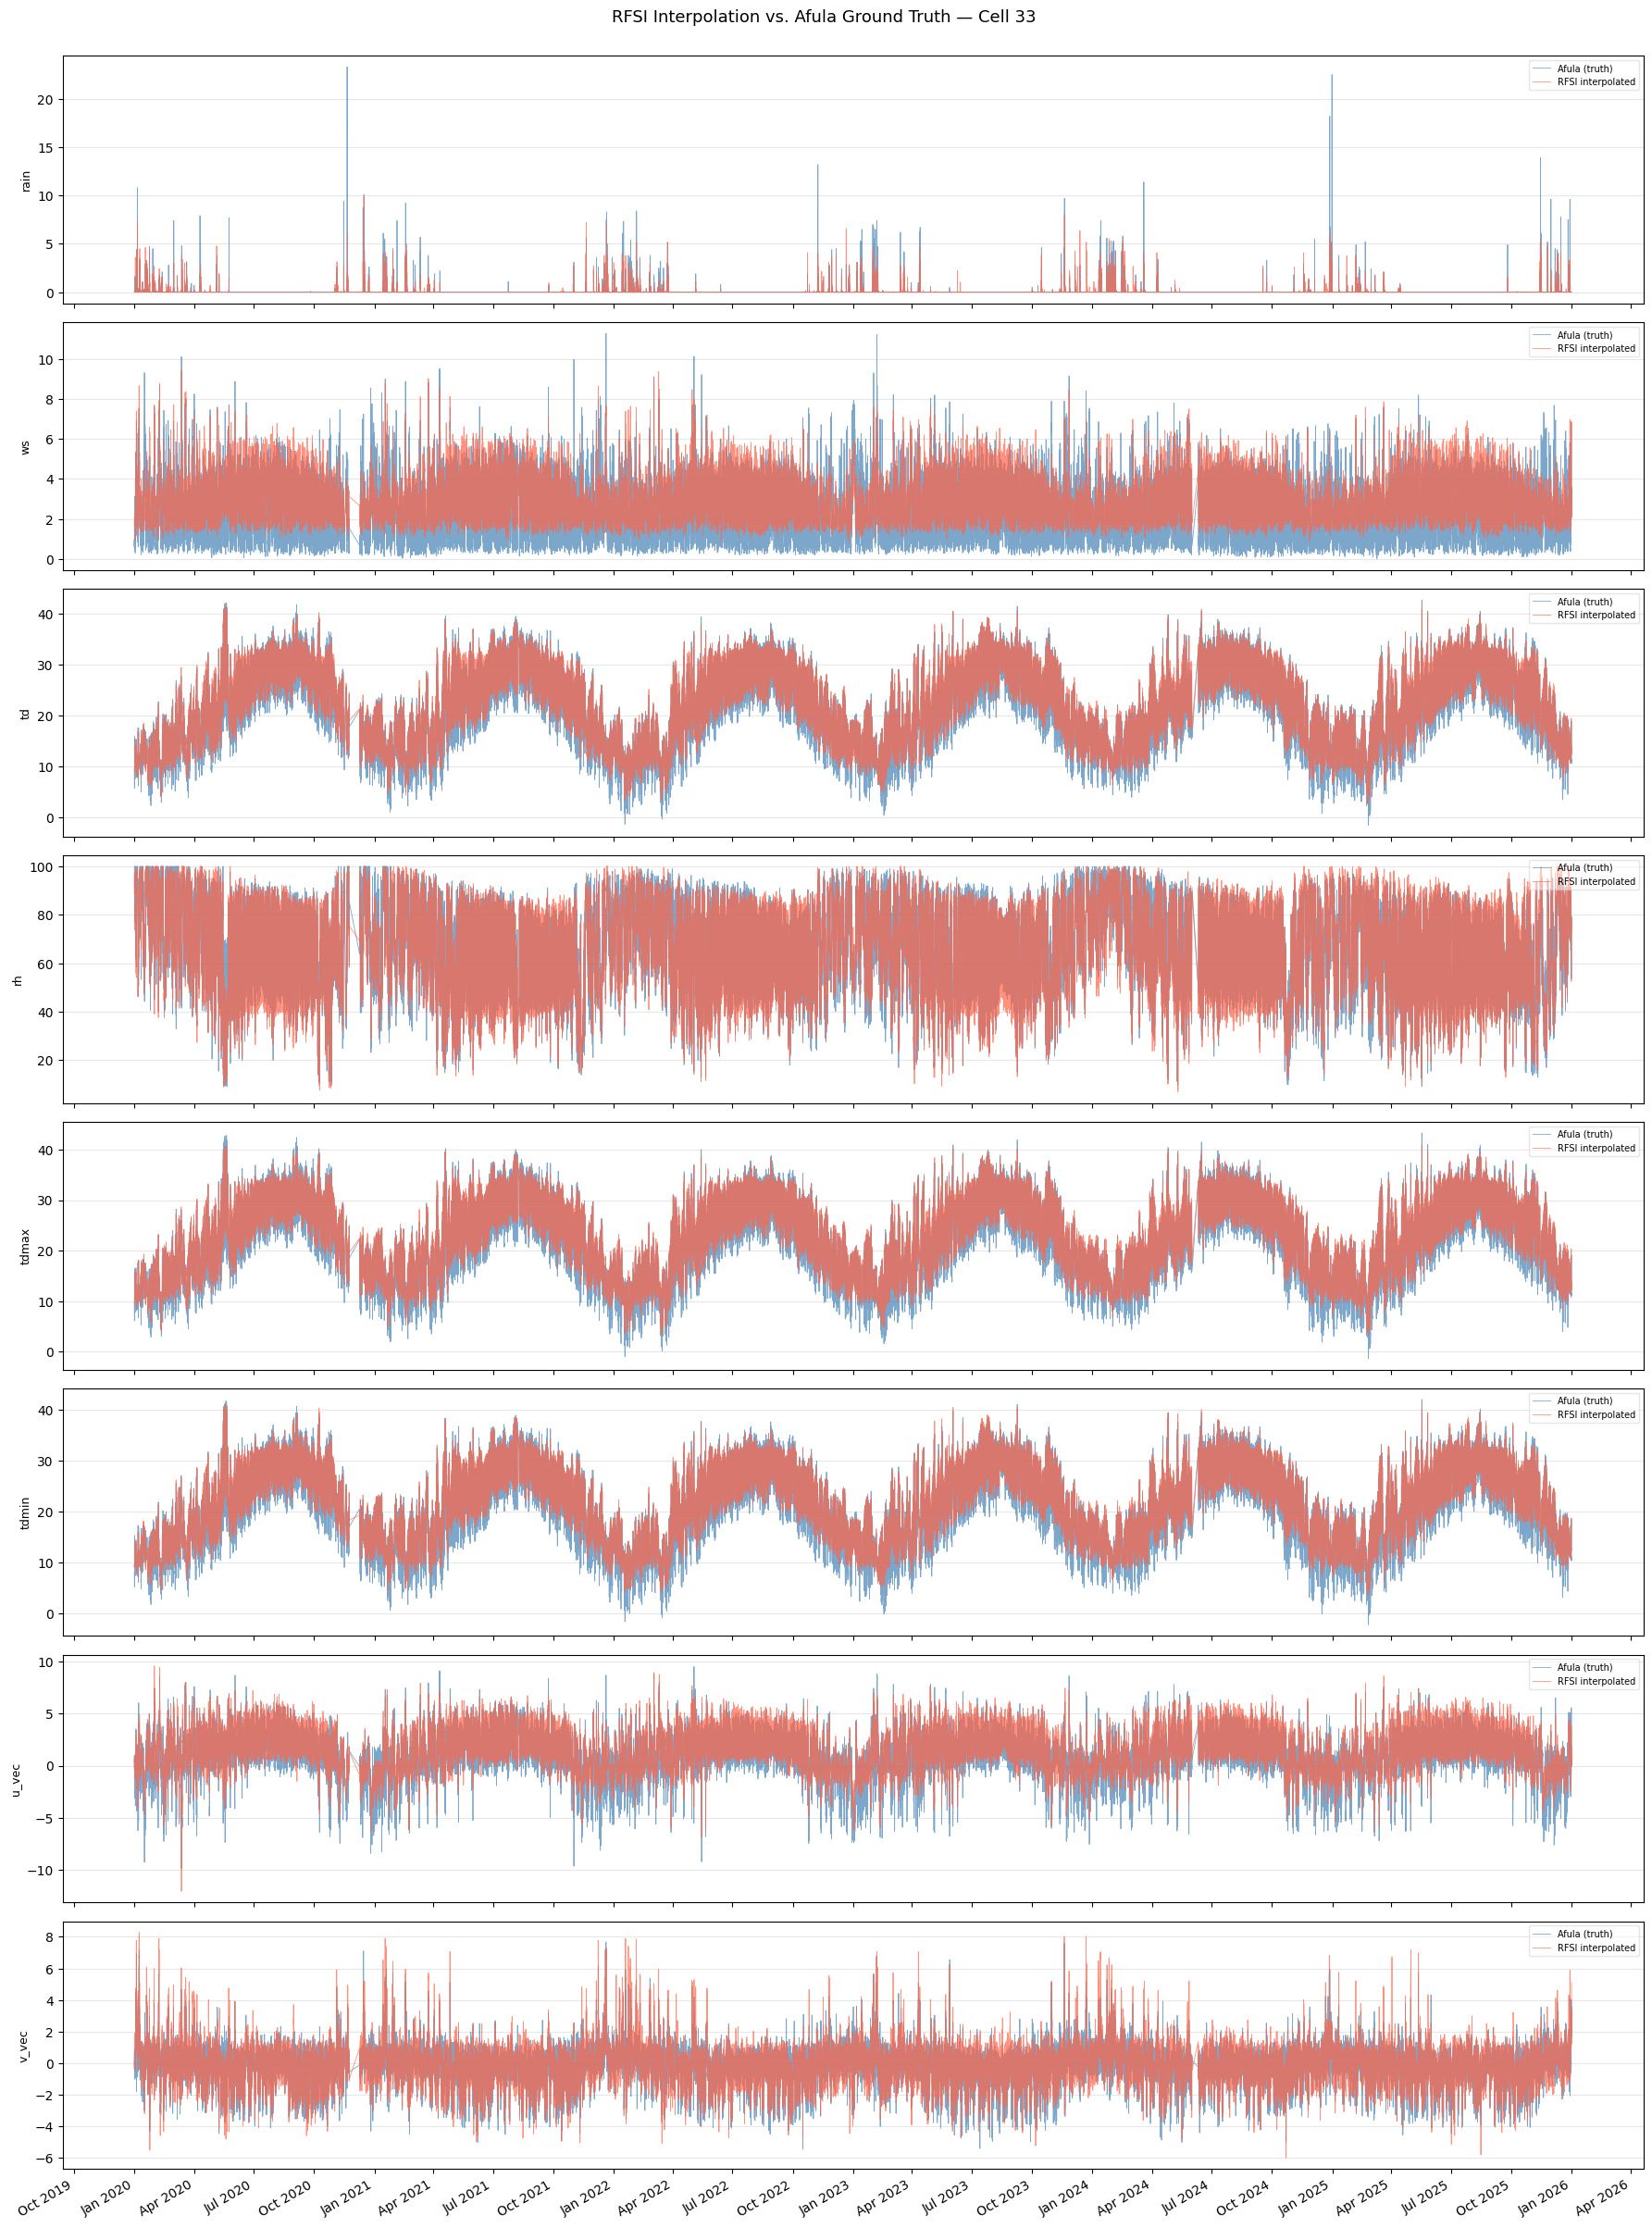

In [5]:
fig, axes = plt.subplots(len(INTERP_FEATURES), 1, figsize=(18, 3 * len(INTERP_FEATURES)), sharex=True)

for ax, feat in zip(axes, INTERP_FEATURES):
    ax.plot(interp_true.index, interp_true[feat], color='steelblue', alpha=0.7, linewidth=0.6, label='Afula (truth)')
    ax.plot(interp_pred.index, interp_pred[feat], color='tomato', alpha=0.7, linewidth=0.6, label='RFSI interpolated')
    ax.set_ylabel(feat, fontsize=9)
    ax.legend(loc='upper right', fontsize=7, framealpha=0.5)
    ax.grid(axis='y', alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.suptitle(f'RFSI Interpolation vs. Afula Ground Truth — Cell {NEAREST_CELL_ID}', fontsize=13, y=1.001)
plt.tight_layout()
plt.show()


## Forecast Accuracy vs. Afula Ground Truth

For each horizon `t+H`, the forecast at timestamp `t` predicts rain at `t+H`.  
So we shift Afula's rain series back by `H` hours to align: `afula['rain'].shift(-H)` gives the future truth at the forecast timestamp.


In [11]:
HORIZONS = {'precipitation_t1': 1, 'precipitation_t3': 3, 'precipitation_t6': 6, 'precipitation_t12': 12}

# Persistence baseline: carry current rain forward (using interpolated rain as "current")
# Align interpolated rain to forecast index for the persistence baseline
interp_rain_for_persistence = interpolated['rain'].reindex(forecasts.index)

rows = []
for col, h in HORIZONS.items():
    # Shift afula rain back by h hours: at forecast time t, truth is afula[t+h]
    future_truth = afula['rain'].shift(-h).reindex(forecasts.index)
    valid = future_truth.notna() & forecasts[col].notna()

    y = future_truth[valid].values
    yhat = forecasts.loc[valid, col].values
    y_persist = interp_rain_for_persistence[valid].values

    mae = mean_absolute_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    bias = np.mean(yhat - y)

    mask_rainy = y >= 0.1
    if mask_rainy.any():
        rmse_storm = np.sqrt(mean_squared_error(y[mask_rainy], yhat[mask_rainy]))
        bias_storm = np.mean(yhat[mask_rainy] - y[mask_rainy])
        rmse_persist_storm = np.sqrt(mean_squared_error(y[mask_rainy], y_persist[mask_rainy]))
    else:
        rmse_storm = bias_storm = rmse_persist_storm = np.nan

    rmse_persist = np.sqrt(mean_squared_error(y, y_persist))
    skill = (rmse_persist_storm - rmse_storm) / rmse_persist_storm * 100

    rows.append({
        'Horizon': f't+{h}h',
        'MAE': mae, 'RMSE': rmse, 'Bias': bias,
        'Storm RMSE': rmse_storm, 'Storm Bias': bias_storm,
        'Persistence RMSE': rmse_persist,
        'Storm Persistence RMSE': rmse_persist_storm,
        'Skill vs Persistence (%)': skill,
        'N valid': valid.sum(),
    })

df_fc_metrics = pd.DataFrame(rows).set_index('Horizon')
display(
    df_fc_metrics.style
    .format({
        'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'Bias': '{:.4f}',
        'Storm RMSE': '{:.4f}', 'Storm Bias': '{:.4f}',
        'Persistence RMSE': '{:.4f}', 'Storm Persistence RMSE': '{:.4f}', 'Skill vs Persistence (%)': '{:.1f}%',
        'N valid': '{:,}'
    })
    .background_gradient(cmap='YlOrRd', subset=['Storm RMSE'])
    .background_gradient(cmap='RdYlGn', subset=['Skill vs Persistence (%)'])
)


,MAE,RMSE,Bias,Storm RMSE,Storm Bias,Persistence RMSE,Storm Persistence RMSE,Skill vs Persistence (%),N valid
Horizon,,,,,,,,,
t+1h,0.0805,0.3834,0.0413,1.6082,-0.0189,0.3990,1.8396,12.6%,"46,746"
t+3h,0.1156,0.4564,0.0695,1.7437,-0.1250,0.4432,1.9885,12.3%,"46,744"
t+6h,0.1477,0.4726,0.1003,1.7209,-0.1697,0.4646,2.0217,14.9%,"46,741"
t+12h,0.1681,0.5127,0.1196,1.7590,-0.1701,0.4889,2.1030,16.4%,"46,735"


## Forecast Timeline Plots (Rain only)

Plot forecast precipitation vs. Afula ground truth for each horizon over a rainy winter season to visually check alignment.


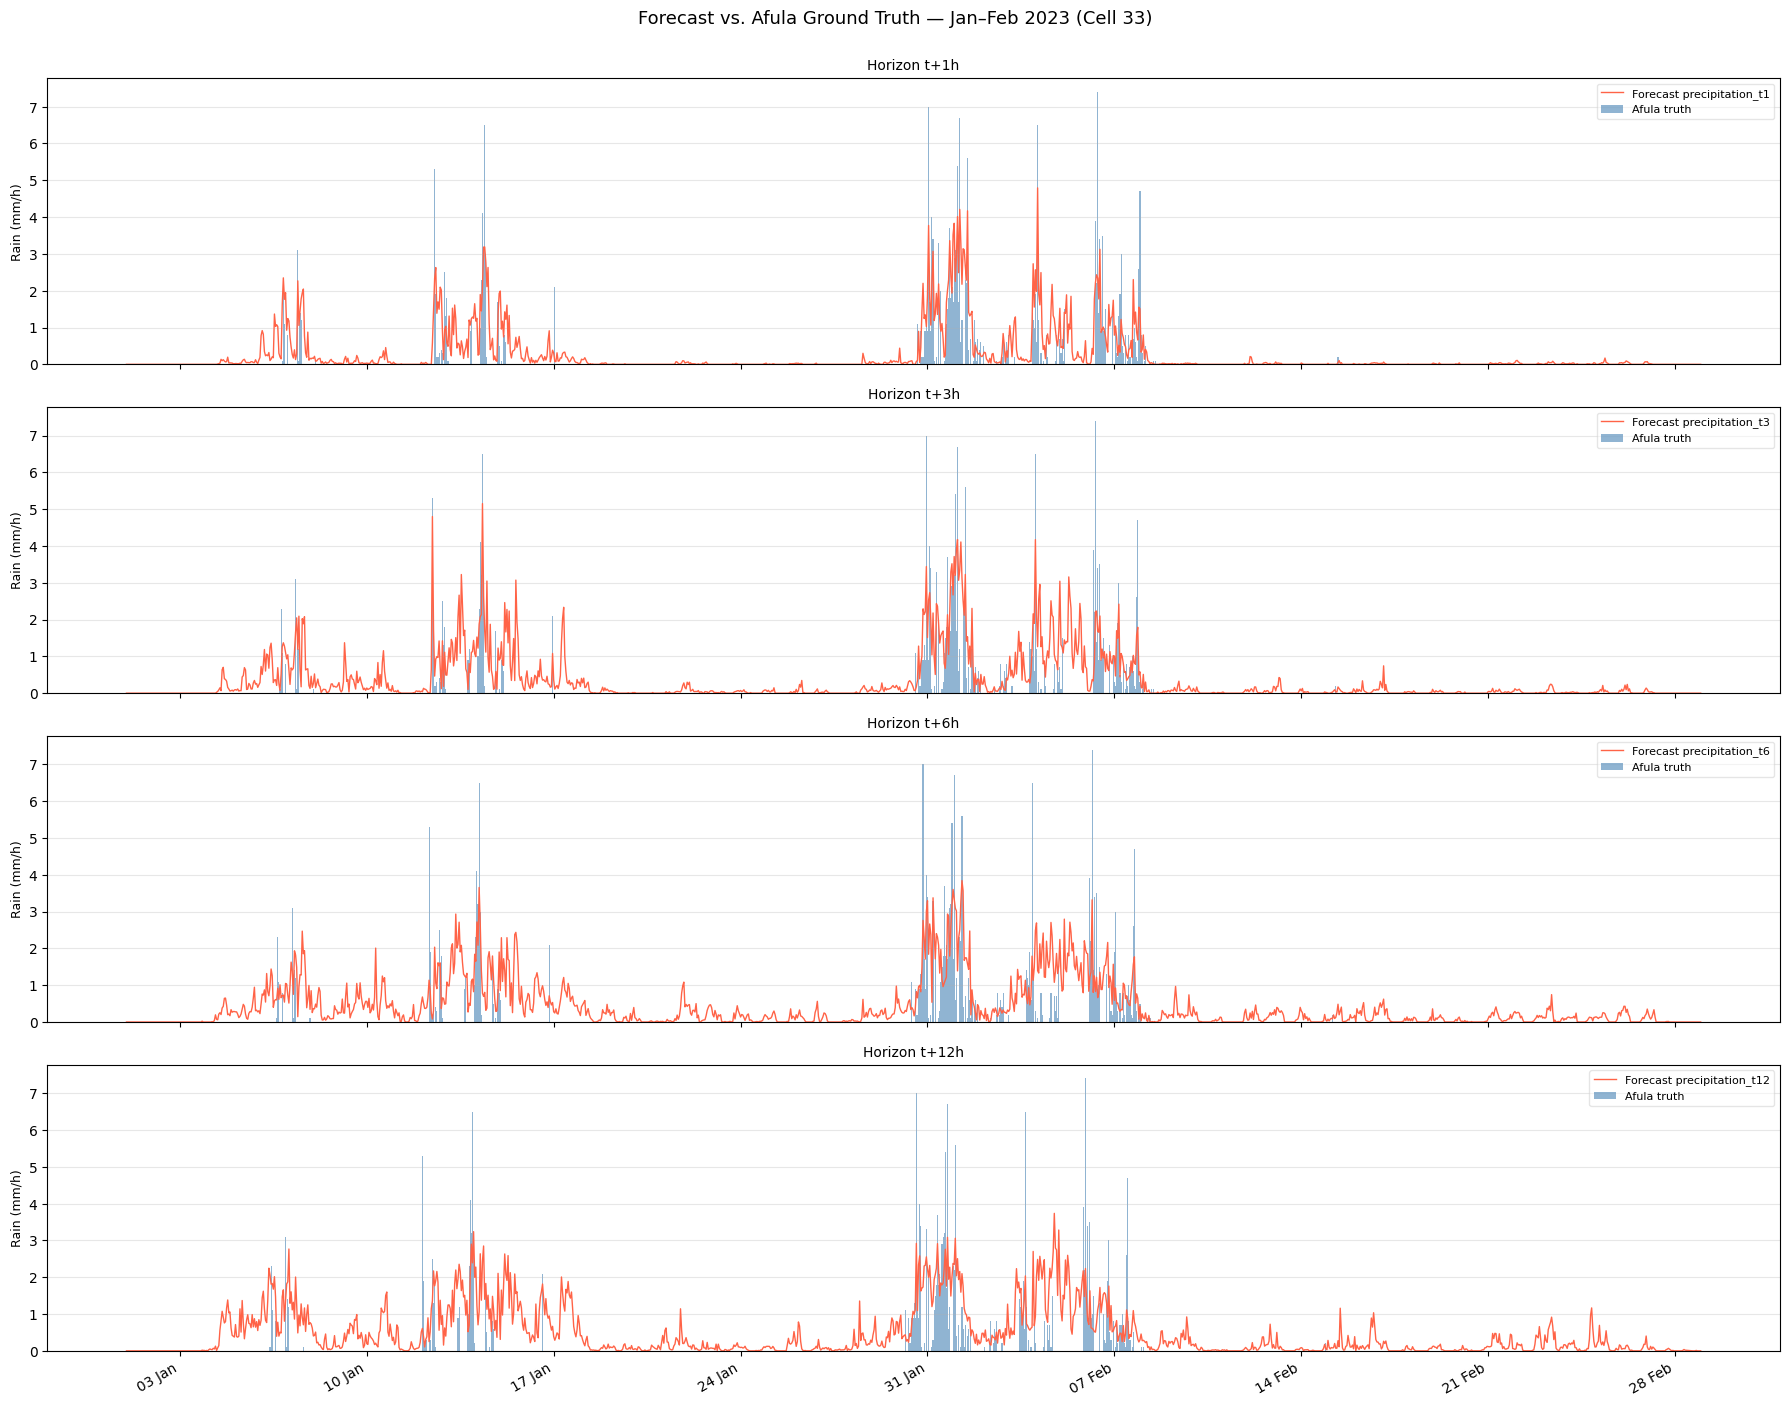

In [7]:
# Zoom into a single rainy winter month for readability
ZOOM_START, ZOOM_END = '2023-01-01', '2023-02-28'

fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(18, 3.5 * len(HORIZONS)), sharex=True)

for ax, (col, h) in zip(axes, HORIZONS.items()):
    future_truth = afula['rain'].shift(-h).reindex(forecasts.index)
    window_truth = future_truth.loc[ZOOM_START:ZOOM_END]
    window_pred  = forecasts.loc[ZOOM_START:ZOOM_END, col]

    ax.bar(window_truth.index, window_truth.values, width=1/24, color='steelblue', alpha=0.6, label='Afula truth')
    ax.plot(window_pred.index, window_pred.values, color='tomato', linewidth=1.0, label=f'Forecast {col}')
    ax.set_ylabel('Rain (mm/h)', fontsize=9)
    ax.set_title(f'Horizon t+{h}h', fontsize=10)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.5)
    ax.grid(axis='y', alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.suptitle(f'Forecast vs. Afula Ground Truth — Jan–Feb 2023 (Cell {NEAREST_CELL_ID})', fontsize=13, y=1.001)
plt.tight_layout()
plt.show()


## Storm Detection (Binary Classification)

Check whether the model can correctly flag rain events (≥ 0.1 mm/h) vs. dry hours for each horizon.


In [8]:
from sklearn.metrics import precision_recall_fscore_support

det_rows = []
for col, h in HORIZONS.items():
    future_truth = afula['rain'].shift(-h).reindex(forecasts.index)
    valid = future_truth.notna() & forecasts[col].notna()

    y = future_truth[valid].values
    yhat = forecasts.loc[valid, col].values

    y_bin   = (y >= 0.1).astype(int)
    yhat_bin = (yhat >= 0.1).astype(int)

    prec, rec, f1, _ = precision_recall_fscore_support(y_bin, yhat_bin, average='binary', zero_division=0)

    storms_missed = int(((y >= 0.1) & (yhat < 0.1)).sum())
    max_missed = y[(y >= 0.1) & (yhat < 0.1)].max() if storms_missed else 0.0

    det_rows.append({
        'Horizon': f't+{h}h',
        'Recall': rec, 'Precision': prec, 'F1': f1,
        'Storms Missed': storms_missed, 'Max Rain Missed (mm/h)': max_missed,
    })

df_det = pd.DataFrame(det_rows).set_index('Horizon')
display(
    df_det.style
    .format({'Recall': '{:.3f}', 'Precision': '{:.3f}', 'F1': '{:.3f}',
             'Storms Missed': '{:,}', 'Max Rain Missed (mm/h)': '{:.2f}'})
    .background_gradient(cmap='RdYlGn', subset=['Recall', 'F1'])
    .background_gradient(cmap='YlOrRd', subset=['Storms Missed'])
)


,Recall,Precision,F1,Storms Missed,Max Rain Missed (mm/h)
Horizon,,,,,
t+1h,0.890,0.336,0.487,205,5.20
t+3h,0.885,0.228,0.363,214,4.90
t+6h,0.905,0.156,0.266,177,5.20
t+12h,0.891,0.155,0.264,202,11.40
